In [49]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [50]:
FEATURE_PATH = "/home/chupchik/Рабочий стол/fisrt_stepD/The_final_recomendation/output_dataset/wazuh_features.parquet"

df = pd.read_parquet(FEATURE_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (2493428, 31)


,scenario,timestamp,agent_id,agent_name,agent_ip,hostname,program,location,full_log,rule_id,...,has_401,has_403,has_500,has_sql,has_admin,has_wp,grp_attack,grp_recon,grp_scan,grp_auth
0,fox,2022-01-15 02:32:32+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:32 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
1,fox,2022-01-15 02:32:32+00:00,6,wazuh-client,192.168.128.170,taylorcruz-mail,freshclam,/var/log/syslog,Jan 15 02:32:32 taylorcruz-mail freshclam[2851...,52507,...,0,0,0,0,0,0,0,0,0,0
2,fox,2022-01-15 02:32:37+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:37 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
3,fox,2022-01-15 02:32:42+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:42 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
4,fox,2022-01-15 02:32:47+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:47 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0


In [51]:
print("Количество столбцов:", len(df.columns))
print(df.columns.tolist())

Количество столбцов: 31
['scenario', 'timestamp', 'agent_id', 'agent_name', 'agent_ip', 'hostname', 'program', 'location', 'full_log', 'rule_id', 'rule_level', 'rule_description', 'rule_groups', 'rule_groups_str', 'y_priority', 'hour', 'dayofweek', 'is_weekend', 'is_night', 'is_internal_ip', 'has_400', 'has_401', 'has_403', 'has_500', 'has_sql', 'has_admin', 'has_wp', 'grp_attack', 'grp_recon', 'grp_scan', 'grp_auth']


In [52]:
target_col = "y_priority"

if target_col not in df.columns:
    raise ValueError("В датасете нет столбца 'y_priority'.")

df = df.dropna(subset=[target_col]).copy()

print(df[target_col].value_counts(dropna=False))
print()
print(df[target_col].value_counts(normalize=True, dropna=False))

y_priority
medium      1873575
low          486285
high         131901
critical       1667
Name: count, dtype: int64

y_priority
medium      0.751405
low         0.195027
high        0.052899
critical    0.000669
Name: proportion, dtype: float64


In [53]:
leakage_cols = [
    "rule_id",
    "rule_level",
    "severity",
    "rule_description",
    "rule_groups"
]

existing_leakage_cols = [c for c in leakage_cols if c in df.columns]
print("Leakage columns found:", existing_leakage_cols)

Leakage columns found: ['rule_id', 'rule_level', 'rule_description', 'rule_groups']


In [54]:
text_candidates = [
    "full_log"
]

numeric_candidates = [
    "hour",
    "dayofweek",
    "is_weekend",
    "is_night",
    "is_internal_ip",
    "has_400",
    "has_401",
    "has_403",
    "has_500",
    "has_sql",
    "has_admin",
    "has_wp"
]

# УБРАЛИ scenario
categorical_candidates = [
    "program",
    "location"
    "scenario"
]

text_features = [c for c in text_candidates if c in df.columns]
numeric_features = [c for c in numeric_candidates if c in df.columns]
categorical_features = [c for c in categorical_candidates if c in df.columns]

print("Text features:", text_features)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Text features: ['full_log']
Numeric features: ['hour', 'dayofweek', 'is_weekend', 'is_night', 'is_internal_ip', 'has_400', 'has_401', 'has_403', 'has_500', 'has_sql', 'has_admin', 'has_wp']
Categorical features: ['program']


In [55]:
used_features = text_features + numeric_features + categorical_features + [target_col]
df_model = df[used_features].copy()

print("Shape before sampling:", df_model.shape)
display(df_model.head())

Shape before sampling: (2493428, 15)


,full_log,hour,dayofweek,is_weekend,is_night,is_internal_ip,has_400,has_401,has_403,has_500,has_sql,has_admin,has_wp,program,y_priority
0,Jan 15 02:32:32 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,low
1,Jan 15 02:32:32 taylorcruz-mail freshclam[2851...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,low
2,Jan 15 02:32:37 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,low
3,Jan 15 02:32:42 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,low
4,Jan 15 02:32:47 mail freshclam[29266]: Sat Jan...,2,5,1,1,1,0,0,0,0,0,0,0,freshclam,low


In [56]:
SAMPLE_N = 300_000   # можно потом попробовать 500_000, если хватит памяти/времени
RANDOM_STATE = 42

if SAMPLE_N is not None and SAMPLE_N < len(df_model):
    df_sample, _ = train_test_split(
        df_model,
        train_size=SAMPLE_N,
        random_state=RANDOM_STATE,
        stratify=df_model[target_col]
    )
else:
    df_sample = df_model.copy()

print("Shape after sampling:", df_sample.shape)
print(df_sample[target_col].value_counts(normalize=True))

Shape after sampling: (300000, 15)
y_priority
medium      0.751407
low         0.195027
high        0.052900
critical    0.000667
Name: proportion, dtype: float64


In [57]:
X = df_sample[text_features + numeric_features + categorical_features].copy()
y = df_sample[target_col].copy()

for col in text_features:
    X[col] = X[col].fillna("").astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300000, 14)
y shape: (300000,)


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (240000, 14) (240000,)
Test : (60000, 14) (60000,)


In [59]:
transformers = []

if len(text_features) > 0:
    text_transformer = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.95,
            sublinear_tf=True,
            max_features=50000
        )),
        ("svd", TruncatedSVD(
            n_components=300,
            random_state=RANDOM_STATE
        ))
    ])
    transformers.append(("text", text_transformer, text_features[0]))

if len(numeric_features) > 0:
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0))
    ])
    transformers.append(("num", numeric_transformer, numeric_features))

if len(categorical_features) > 0:
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [60]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape :", X_test_prepared.shape)
print("Prepared type:", type(X_train_prepared))

Prepared train shape: (240000, 313)
Prepared test shape : (60000, 313)
Prepared type: <class 'numpy.ndarray'>


In [61]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample"
)

rf_model.fit(X_train_prepared, y_train)
print("RandomForest training finished.")

RandomForest training finished.


In [62]:
y_pred_rf = rf_model.predict(X_test_prepared)

rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")
rf_weighted_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print(f"RandomForest Macro F1   : {rf_macro_f1:.4f}")
print(f"RandomForest Weighted F1: {rf_weighted_f1:.4f}")
print()
print(classification_report(y_test, y_pred_rf, digits=4))

RandomForest Macro F1   : 0.5053
RandomForest Weighted F1: 0.8732

              precision    recall  f1-score   support

    critical     0.0215    0.1250    0.0366        40
        high     0.0662    0.1339    0.0886      3174
         low     0.9997    0.9997    0.9997     11702
      medium     0.9334    0.8622    0.8964     45084

    accuracy                         0.8500     60000
   macro avg     0.5052    0.5302    0.5053     60000
weighted avg     0.8999    0.8500    0.8732     60000



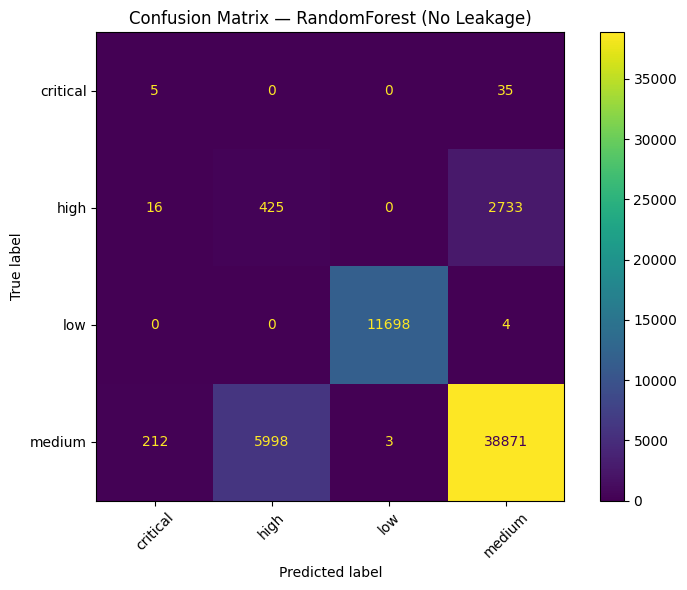

In [63]:
labels = sorted(y.unique())
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix — RandomForest (No Leakage)")
plt.tight_layout()
plt.show()